# Luas Green Line × RTB Rent Index — data exploration

Before any analysis, this notebook gets familiar with the two datasets and
documents the data-quality decisions the rest of the project relies on.

**Sources**

- RTB Average Monthly Rent Report (CSO PxStat table `RIA02`), annual 2008–2025
- Luas stop locations from Transport Infrastructure Ireland

**Prerequisites** — run these once from the project root:

```
python src/data_loader.py        # downloads the raw data, builds the CSVs
python src/sql_utils.py --build  # builds database/rent_data.db
```

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.append(str(ROOT / "src"))

from sql_utils import run_sql, run_query_file

pd.set_option("display.max_columns", None)

## 1. The stations

One row per Green Line stop, ordered from St. Stephen's Green (the city
centre) out to Brides Glen. Coordinates come from the official TII file;
`rtb_location_area` is the RTB reporting area each station was matched to,
and is the join key between the two datasets.

In [2]:
stations = pd.read_csv(ROOT / "data" / "luas_stations.csv")
stations

,stop_sequence,station,latitude,longitude,distance_km_to_centre,travel_min_to_centre,rtb_location_area,rtb_location_district,park_and_ride
0,0,St. Stephen's Green,53.339072,-6.261333,0.00,0,"Charlemont Street, Dublin 2",Dublin 2,0
1,1,Harcourt,53.333358,-6.262650,0.64,2,"Charlemont Street, Dublin 2",Dublin 2,0
2,2,Charlemont,53.330669,-6.258683,0.95,4,"Charlemont Street, Dublin 2",Dublin 2,0
3,3,Ranelagh,53.326433,-6.256203,1.45,7,"Ranelagh, Dublin 6",Dublin 6,0
4,4,Beechwood,53.320822,-6.254653,2.08,9,"Ranelagh, Dublin 6",Dublin 6,0
5,5,Cowper,53.316467,-6.253447,2.57,11,"Ranelagh, Dublin 6",Dublin 6,0
6,6,Milltown,53.309917,-6.251728,3.30,13,"Milltown, Dublin 6",Dublin 6,0
7,7,Windy Arbour,53.301558,-6.250708,4.23,15,"Churchtown, Dublin 14",Dublin 14,0
8,8,Dundrum,53.292358,-6.245117,5.30,17,"Dundrum, Dublin 16",Dublin 14,0
9,9,Balally,53.286106,-6.236772,6.11,19,"Dundrum, Dublin 16",Dublin 16,1


In [3]:
import folium

m = folium.Map(
    location=[stations["latitude"].mean(), stations["longitude"].mean()],
    zoom_start=12,
    tiles="cartodbpositron",
)
for _, s in stations.iterrows():
    folium.CircleMarker(
        [s["latitude"], s["longitude"]],
        radius=6, fill=True, fill_opacity=0.8,
        popup=f"{s['station']} ({s['travel_min_to_centre']} min)",
    ).add_to(m)
m

## 2. The rent data

`rents` holds one row per year × bedroom count × property type × RTB
location, for the 16 locations our stations map to plus the Dublin county
benchmark.

In [4]:
rents = run_sql("SELECT * FROM rents")
print(rents.shape)
rents.head()

(5842, 6)


,rent_id,year,bedrooms,property_type,location,avg_rent
0,1,2008,All bedrooms,All property types,Dublin,1271.28
1,2,2008,All bedrooms,All property types,"Shankill, Dublin",1382.30
2,3,2008,All bedrooms,All property types,"Stillorgan, Dublin",1569.16
3,4,2008,All bedrooms,All property types,Dublin 2,1411.67
4,5,2008,All bedrooms,All property types,"Charlemont Street, Dublin 2",1506.83


### Coverage check: which locations report in which years?

The pivot below counts published figures per location and year (headline
'All bedrooms / All property types' slice).

In [5]:
headline = rents[
    (rents["bedrooms"] == "All bedrooms")
    & (rents["property_type"] == "All property types")
]
coverage = headline.pivot_table(
    index="location", columns="year", values="avg_rent", aggfunc="size", fill_value=0
)
coverage

year,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
location,,,,,,,,,,,,,,,,,,
"Cabinteely, Dublin 18",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"Carrickmines, Dublin 18",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"Charlemont Street, Dublin 2",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"Churchtown, Dublin 14",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Dublin,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Dublin 14,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0
Dublin 16,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0
Dublin 18,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0
Dublin 2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0


Two things stand out:

1. **The Dublin postal-district series (Dublin 2, Dublin 6, ...) stop in
   2021.** The RTB changed its reporting geography that year. This is why
   every station was mapped to a *suburb-level* location (`Ranelagh,
   Dublin 6`, `Carrickmines, Dublin 18`, ...) — those series run all the
   way from 2008 to 2025. The district columns are kept only as a
   smoother fallback for early years.
2. The suburb series are complete for the headline slice — no gaps.

### Suppression: not every slice is published everywhere

The RTB withholds a figure when an area has too few registered tenancies
of that type. Slicing 2025 by bedroom count shows the holes:

In [6]:
beds_2025 = (
    rents[(rents["year"] == 2025) & (rents["property_type"] == "All property types")]
    .pivot_table(index="location", columns="bedrooms", values="avg_rent")
    .round()
)
beds_2025

bedrooms,1 to 2 bed,1 to 3 bed,All bedrooms,Four plus bed,One bed,Three bed,Two bed
location,,,,,,,
"Cabinteely, Dublin 18",2041.0,2198.0,2324.0,NaN,NaN,NaN,2088.0
"Carrickmines, Dublin 18",2032.0,2104.0,2288.0,NaN,NaN,NaN,2162.0
"Charlemont Street, Dublin 2",2119.0,2226.0,2226.0,NaN,NaN,NaN,NaN
"Churchtown, Dublin 14",2412.0,2486.0,2573.0,NaN,2015.0,2726.0,2568.0
Dublin,2013.0,2094.0,2159.0,3330.0,1736.0,2567.0,2247.0
"Dundrum, Dublin 16",2227.0,2303.0,2336.0,3305.0,2042.0,2934.0,2338.0
"Leopardstown, Dublin 18",2050.0,2159.0,2177.0,NaN,1836.0,2659.0,2137.0
"Milltown, Dublin 6",2179.0,2277.0,2322.0,NaN,1849.0,2885.0,2370.0
"Ranelagh, Dublin 6",1784.0,1956.0,2093.0,4804.0,1585.0,3287.0,2288.0


`Charlemont Street, Dublin 2` — the area covering the three city-centre
stops — has no standalone `Two bed` figure at all (it is an
apartment-heavy area where the RTB only publishes grouped slices).

**`1 to 2 bed` is the only controlled slice published for every area on
the line**, so all like-for-like comparisons in this project standardise
on it. Using the headline 'All bedrooms' figure to compare stations would
mix studio apartments in town with four-bed houses in Dublin 18 — see the
analysis notebook for how badly that misleads.

## 3. A first look at the series

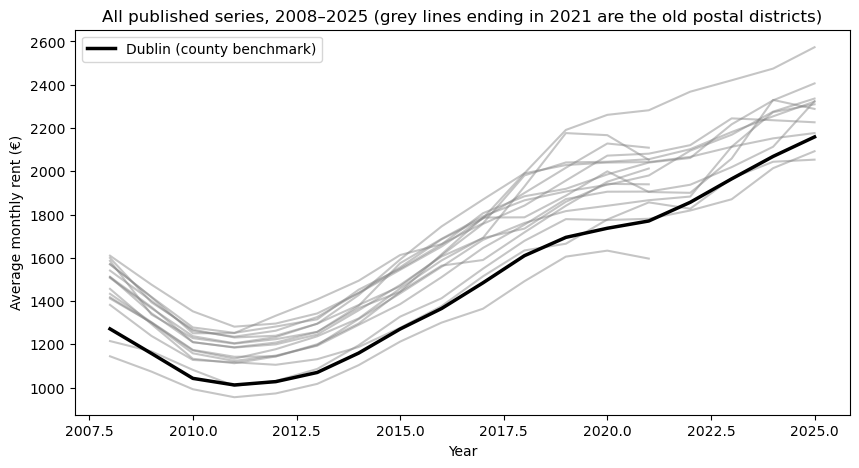

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for loc, grp in headline.groupby("location"):
    if loc == "Dublin":
        ax.plot(grp["year"], grp["avg_rent"], color="black", linewidth=2.5,
                label="Dublin (county benchmark)", zorder=3)
    else:
        ax.plot(grp["year"], grp["avg_rent"], color="grey", alpha=0.45)
ax.set_xlabel("Year")
ax.set_ylabel("Average monthly rent (€)")
ax.set_title("All published series, 2008–2025 (grey lines ending in 2021 are the old postal districts)")
ax.legend()
plt.show()

The shape is the familiar Irish story: the post-2008 crash bottoming out
around 2011–2012, then a long climb that roughly doubled rents by 2025.
The grey lines that stop mid-chart are the discontinued district series —
a visual reminder of why the suburb mapping matters.

## Takeaways

- Join key: `stations.rtb_location_area` → `rents.location`, complete 2008–2025.
- District series end in 2021; never mix them with suburb series in a trend.
- All station-vs-station comparisons use `bedrooms = '1 to 2 bed'`.
- NULLs in sliced data are RTB suppression, not missing downloads.